# Lab 8: Custom CNN Model for Corn Leaf Image Classification

**Student Name:** DANIYAL BASHARAT  
**Registration Number:** 22JZELE0467  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Lab Overview
This notebook builds and trains a custom Convolutional Neural Network for corn leaf image classification. The code uses TensorFlow/Keras, ImageDataGenerator, model checkpoints, training history plots, and classification metrics for evaluation.

## Learning Objectives
- Import TensorFlow/Keras layers, models, optimizers, and image preprocessing tools.
- Load images from train, validation, and test directories using ImageDataGenerator.
- Build and compile a custom CNN model for multi-class image classification.
- Train the CNN model and monitor validation performance using checkpoints.
- Evaluate the trained model using accuracy, confusion matrix, and classification report.

## Section 1: Library Import and Path Setup
This section imports Keras, plotting, NumPy, and evaluation libraries, then defines checkpoint and dataset paths.


# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [2]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [3]:
checkpoints = r'Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [4]:
train_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\train'
validation_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\validation'
test_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\test'

## Section 2: CNN Architecture Design
The following cells create the CNN model using convolution, pooling, flattening, dense, and output layers.


In [5]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

c:\Users\engin\.conda\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators and Model Training
This section loads image batches from folders, applies rescaling, sets checkpoints, and trains the CNN model.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [ ]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=100,
                    callbacks=callbacks)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4323 - loss: 1.2526
Epoch 1: val_loss improved from None to 1.02704, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0001-loss1.03.h5



Epoch 1: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0001-loss1.03.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5312 - loss: 1.0621 - val_accuracy: 0.5873 - val_loss: 1.0270
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7330 - loss: 0.6547
Epoch 2: val_loss improved from 1.02704 to 0.70310, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0002-loss0.70.h5



Epoch 2: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0002-loss0.70.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7650 - loss: 0.5639 - val_accuracy: 0.6468 - val_loss: 0.7031
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8329 - loss: 0.4138
Epoch 3: val_loss improved from 0.70310 to 0.35998, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0003-loss0.36.h5



Epoch 3: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0003-loss0.36.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8112 - loss: 0.4148 - val_accuracy: 0.8294 - val_loss: 0.3600
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8429 - loss: 0.3337
Epoch 4: val_loss improved from 0.35998 to 0.32457, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0004-loss0.32.h5



Epoch 4: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0004-loss0.32.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8363 - loss: 0.3447 - val_accuracy: 0.8651 - val_loss: 0.3246
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8561 - loss: 0.3141
Epoch 5: val_loss did not improve from 0.32457
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8612 - loss: 0.2994 - val_accuracy: 0.8214 - val_loss: 0.3979
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8643 - loss: 0.2857
Epoch 6: val_loss did not improve from 0.32457
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8800 - loss: 0.2709 - val_accuracy: 0.8413 - val_loss: 0.3614
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8947 - loss: 0.2679
Epoch 7: val_loss improved from 0.32457 to 0.26409, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0007-loss0.26.h5



Epoch 7: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0007-loss0.26.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9062 - loss: 0.2342 - val_accuracy: 0.8929 - val_loss: 0.2641
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9006 - loss: 0.2155
Epoch 8: val_loss did not improve from 0.26409
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9062 - loss: 0.2133 - val_accuracy: 0.8571 - val_loss: 0.2981
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9302 - loss: 0.1674
Epoch 9: val_loss improved from 0.26409 to 0.25263, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0009-loss0.25.h5



Epoch 9: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0009-loss0.25.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9200 - loss: 0.1831 - val_accuracy: 0.8849 - val_loss: 0.2526
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9414 - loss: 0.1669
Epoch 10: val_loss did not improve from 0.25263
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9325 - loss: 0.1731 - val_accuracy: 0.8770 - val_loss: 0.2694
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9504 - loss: 0.1448
Epoch 11: val_loss did not improve from 0.25263
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9450 - loss: 0.1551 - val_accuracy: 0.8651 - val_loss: 0.3137
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9421 - loss: 0.1346
Epoch 12: val_loss did not improve from 0.25263
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9381 - loss: 0.1467 - val_accuracy: 0.8373 - val_loss: 0.3635
Epoch 13/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model_history.history

{'accuracy': [0.5274999737739563,
  0.7743750214576721,
  0.8012499809265137,
  0.8450000286102295,
  0.856249988079071,
  0.8793749809265137,
  0.8912500143051147,
  0.90625,
  0.9225000143051147,
  0.9237499833106995,
  0.9287499785423279,
  0.9368749856948853,
  0.9468749761581421,
  0.940625011920929,
  0.9456250071525574,
  0.9606249928474426,
  0.9593750238418579,
  0.965624988079071,
  0.9737499952316284,
  0.96875,
  0.9756249785423279,
  0.9793750047683716,
  0.981249988079071,
  0.987500011920929,
  0.9862499833106995,
  0.9850000143051147,
  0.9925000071525574,
  0.9943749904632568,
  0.9943749904632568,
  0.9912499785423279,
  0.996874988079071,
  0.9993749856948853,
  0.9918749928474426,
  0.9987499713897705,
  1.0,
  0.996874988079071,
  1.0,
  0.9906250238418579,
  0.9993749856948853,
  0.9981250166893005,
  0.9943749904632568,
  0.9981250166893005,
  1.0,
  0.9918749928474426,
  1.0,
  0.996874988079071,
  1.0,
  1.0,
  0.9962499737739563,
  1.0,
  1.0,
  1.0,
  1.0,
  

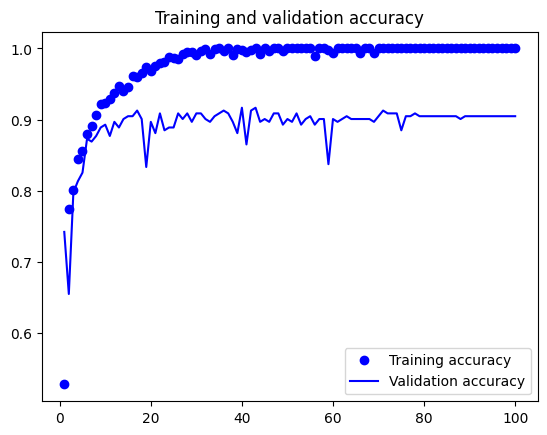

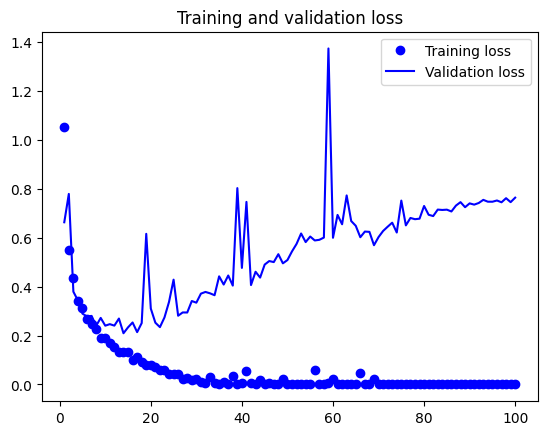

In [ ]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\model_Loss.png')

plt.show()

## Section 4: Model Evaluation and Visualization
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


In [ ]:
model.save(r'Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0014-loss0.21.h5')

Found 200 images belonging to 4 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 569ms/step


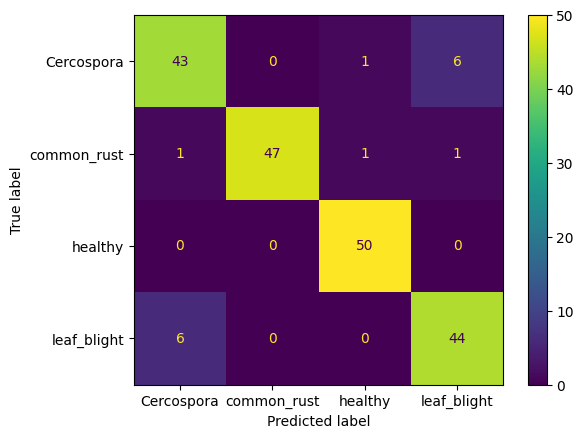

In [ ]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\confusion_matrics.jpg')

In [ ]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.86      0.86      0.86        50
 common_rust       1.00      0.94      0.97        50
     healthy       0.96      1.00      0.98        50
 leaf_blight       0.86      0.88      0.87        50

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



## Final Conclusion
In this lab, a custom CNN was trained for corn leaf image classification using the prepared dataset. The model was evaluated using visual training curves and classification metrics.

## Submitted By
**Student Name:** DANIYAL BASHARAT  
**Registration Number:** 22JZELE0467  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus
